# L6 Feature Tables — Visualization

Trực quan hoá ma trận **X / y / group** mà LightGBM LambdaRank (L6) huấn luyện.

**Nguồn:** `results/m4_v2/cache/ltr_features/{ds}.npz` (6 dataset).
Mỗi dòng = 1 cặp (query, candidate); `X` = 45 feature; `y=1` nếu candidate là gold; 
`group_sizes` = số candidate/query (~500). Tổng ~2.7 triệu dòng, ~7.381 dương.

Các file npz được sinh từ `data/bench/instances` (query+gold) + `corpus.json` + 
`results/bge/corpus_emb.npy` + `results/clusters*` + `results/m4_v2/cache/{query_emb,fused_pool,cluster_stats}` + `results/retrieval_bm25`.


## 0. Setup


In [ ]:
import sys, os, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# tìm repo root (chứa 'results' + 'src') rồi nạp package kmeans
ROOT = Path.cwd().resolve()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src")); os.chdir(ROOT)
from kmeans import ltr_features
DATASETS = ["theoremqa", "logicbench", "toolqa", "champ", "medcalcbench", "bigcodebench"]
FEATS = ltr_features.ALL_FEATURES
GROUPS = ltr_features.FEATURE_GROUPS
print("repo root :", ROOT)
print("features  :", len(FEATS))
plt.rcParams["figure.dpi"] = 110


repo root : /Users/hiro/Documents/Vinuni/code/SRA
features  : 45


In [3]:
print("featx: ", FEATS)

featx:  ['rrf_score', 'rrf_norm', 'rrf_rank', 'bm25_score', 'bm25_norm', 'bm25_rank', 'bge_score', 'bge_norm', 'bge_rank', 'direct_cosine_q_s', 'inv_rrf_rank', 'inv_bm25_rank', 'inv_bge_rank', 'missing_bm25_flag', 'missing_bge_flag', 'm4_score', 'm4_rank', 'm4_affinity', 'm4_aff_norm', 'global_cluster_id', 'global_cluster_size', 'global_cluster_cohesion', 'global_cluster_reliability', 'prf_score', 'prf_rank', 'prf_query_shift_norm', 'prf_safe_set_size', 'prf_safe_set_mean_rrf', 'cosine_refined_query_skill', 'qsc_local_affinity', 'qsc_local_aff_norm', 'qsc_local_prior', 'qsc_local_prior_norm', 'qsc_local_centrality', 'qsc_local_cluster_id', 'qsc_local_cluster_size', 'qsc_local_cluster_rank_by_prior', 'qsc_local_cluster_rank_by_affinity', 'rrf_margin_1_10', 'rrf_margin_1_5', 'bm25_bge_top10_overlap', 'bm25_bge_top20_overlap', 'bm25_bge_top50_overlap', 'query_cluster_entropy_global', 'query_length_tokens']


## 1. Nạp 6 feature table + ghép lại


In [4]:
data = {ds: ltr_features.load_features(ROOT / f"results/m4_v2/cache/ltr_features/{ds}.npz")
        for ds in DATASETS}
Xall = np.concatenate([data[ds]["X"] for ds in DATASETS]).astype(np.float32)
yall = np.concatenate([data[ds]["y"] for ds in DATASETS]).astype(np.int8)
dsall = np.concatenate([np.full(len(data[ds]["y"]), ds) for ds in DATASETS])
print("Xall:", Xall.shape, "| positives (gold):", int(yall.sum()),
      f"({100*yall.mean():.3f}%)")


Xall: (2700000, 45) | positives (gold): 7381 (0.273%)


In [6]:
np.unique(dsall), np.unique(yall), np.unique(Xall, axis=0).shape

(array(['bigcodebench', 'champ', 'logicbench', 'medcalcbench', 'theoremqa',
        'toolqa'], dtype='<U12'),
 array([0, 1], dtype=int8),
 (2695500, 45))

In [5]:
dsall[0:10], yall[0:10], Xall[0:10, 0:5]

(array(['theoremqa', 'theoremqa', 'theoremqa', 'theoremqa', 'theoremqa',
        'theoremqa', 'theoremqa', 'theoremqa', 'theoremqa', 'theoremqa'],
       dtype='<U12'),
 array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8),
 array([[3.2522473e-02, 1.0000000e+00, 1.0000000e+00, 4.8683247e+01,
         8.0880314e-01],
        [3.2522473e-02, 1.0000000e+00, 2.0000000e+00, 6.0191711e+01,
         1.0000000e+00],
        [3.1250000e-02, 9.5848823e-01, 3.0000000e+00, 3.5678589e+01,
         5.9274918e-01],
        [3.0798389e-02, 9.4375533e-01, 4.0000000e+00, 2.5962561e+01,
         4.3133116e-01],
        [3.0798389e-02, 9.4375533e-01, 5.0000000e+00, 3.6812111e+01,
         6.1158109e-01],
        [3.0090498e-02, 9.2066193e-01, 6.0000000e+00, 3.4540680e+01,
         5.7384443e-01],
        [2.9857397e-02, 9.1305751e-01, 7.0000000e+00, 2.4731882e+01,
         4.1088519e-01],
        [2.8577261e-02, 8.7129569e-01, 8.0000000e+00, 1.8979639e+01,
         3.1531981e-01],
        [2.8309410e-02, 8.6

## 2. Tổng quan theo dataset


In [7]:
rows = []
for ds in DATASETS:
    d = data[ds]; n = d["X"].shape[0]; pos = int(d["y"].sum()); q = len(d["group_sizes"])
    rows.append(dict(dataset=ds, rows=n, queries=q, cand_per_query=round(n/q, 1),
                     gold_rows=pos, pct_gold=round(100*pos/n, 3)))
rows.append(dict(dataset="TOTAL", rows=Xall.shape[0],
                 queries=sum(len(data[ds]["group_sizes"]) for ds in DATASETS),
                 cand_per_query=round(Xall.shape[0]/sum(len(data[ds]["group_sizes"]) for ds in DATASETS), 1),
                 gold_rows=int(yall.sum()), pct_gold=round(100*yall.mean(), 3)))
ov = pd.DataFrame(rows); ov


,dataset,rows,queries,cand_per_query,gold_rows,pct_gold
0,theoremqa,373500,747,500.0,741,0.198
1,logicbench,380000,760,500.0,660,0.174
2,toolqa,715000,1430,500.0,1412,0.197
3,champ,111500,223,500.0,381,0.342
4,medcalcbench,550000,1100,500.0,1099,0.200
5,bigcodebench,570000,1140,500.0,3088,0.542
6,TOTAL,2700000,5400,500.0,7381,0.273


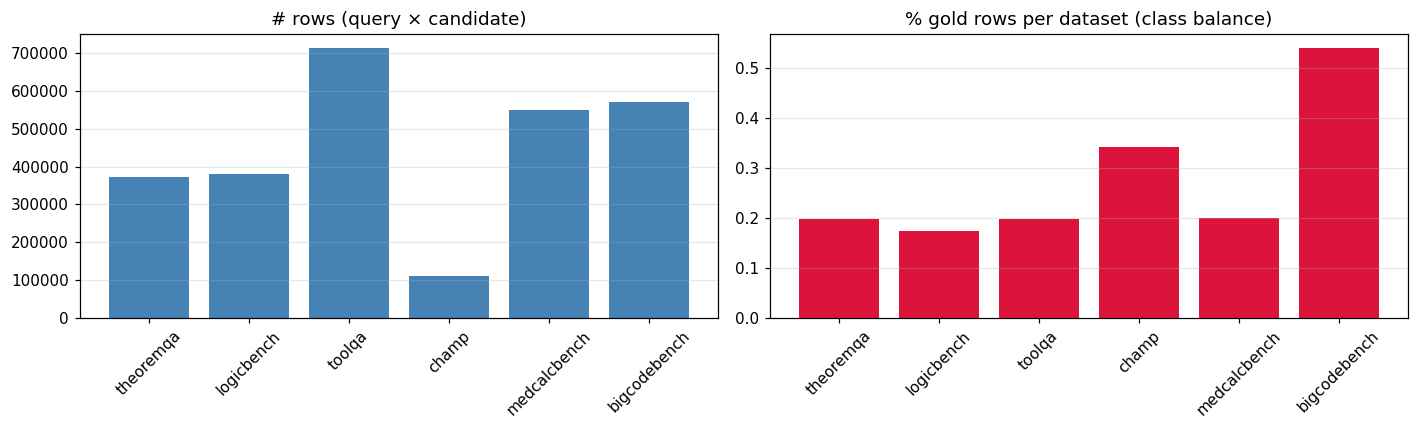

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(DATASETS, [data[ds]["X"].shape[0] for ds in DATASETS], color="steelblue")
ax[0].set_title("# rows (query × candidate)"); ax[0].tick_params(axis="x", rotation=45)
ax[1].bar(DATASETS, [100*data[ds]["y"].mean() for ds in DATASETS], color="crimson")
ax[1].set_title("% gold rows per dataset (class balance)"); ax[1].tick_params(axis="x", rotation=45)
for a in ax: a.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Phân phối của 45 feature (subsample 200k dòng)


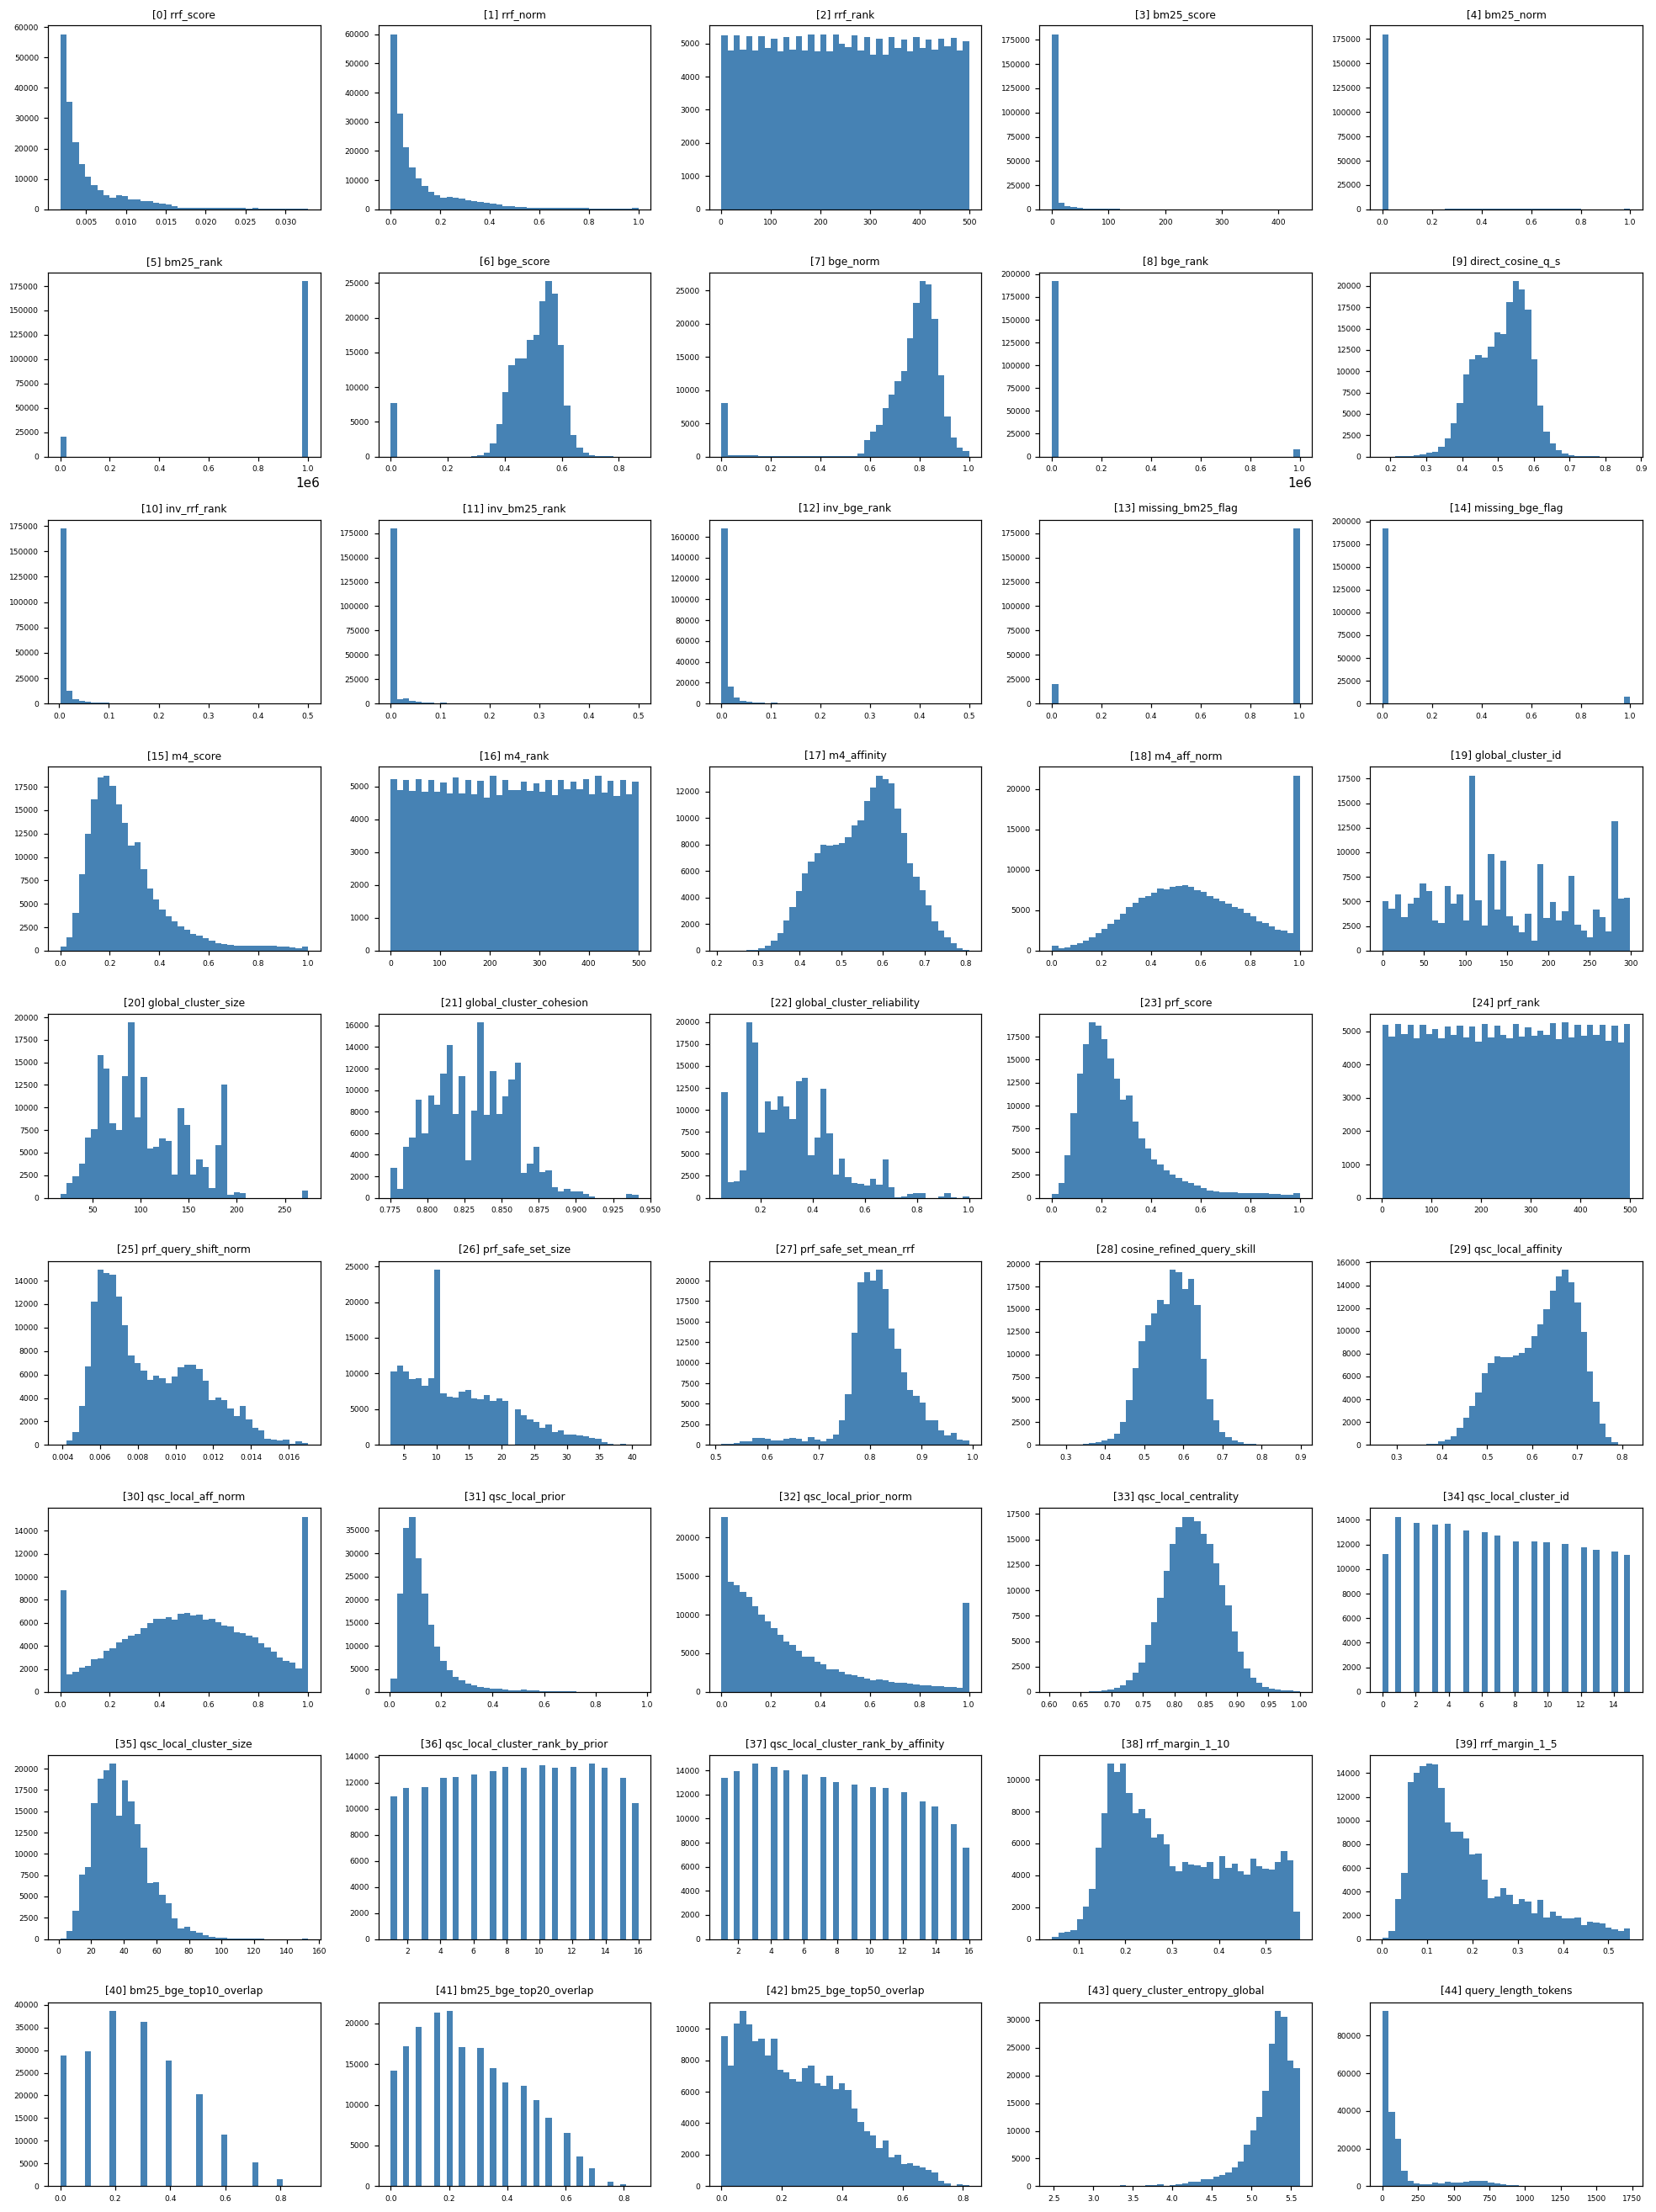

In [9]:
rng = np.random.default_rng(0)
sidx = rng.choice(Xall.shape[0], size=min(200_000, Xall.shape[0]), replace=False)
Xs, ys = Xall[sidx], yall[sidx]
fig, axes = plt.subplots(9, 5, figsize=(18, 24))
for i, (name, ax) in enumerate(zip(FEATS, axes.ravel())):
    ax.hist(Xs[:, i], bins=40, color="steelblue")
    ax.set_title(f"[{i}] {name}", fontsize=8); ax.tick_params(labelsize=6)
for ax in axes.ravel()[len(FEATS):]: ax.axis("off")
plt.tight_layout(); plt.show()


## 4. Feature nào phân biệt gold? (standardized mean difference)

Hiệu trung bình chuẩn hoá `(mean_gold − mean_nongold)/std`. Càng dương → feature đó **cao hơn ở gold**.


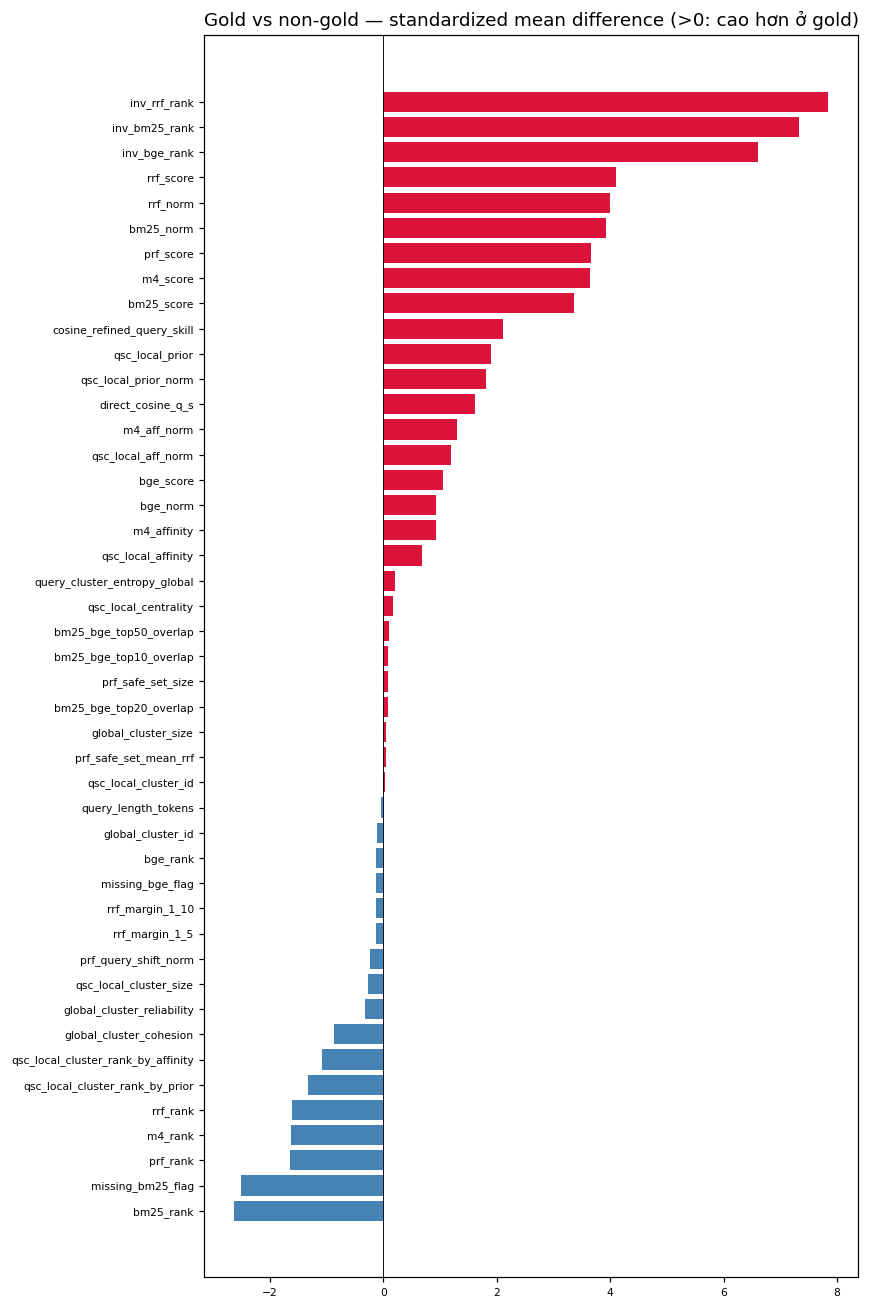

In [10]:
mg, mn = Xall[yall == 1].mean(0), Xall[yall == 0].mean(0)
eff = (mg - mn) / (Xall.std(0) + 1e-9)
order = np.argsort(eff)
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh([FEATS[i] for i in order], eff[order],
        color=["crimson" if eff[i] > 0 else "steelblue" for i in order])
ax.axvline(0, color="k", lw=0.6)
ax.set_title("Gold vs non-gold — standardized mean difference (>0: cao hơn ở gold)")
ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()


## 5. Tương quan giữa 45 feature


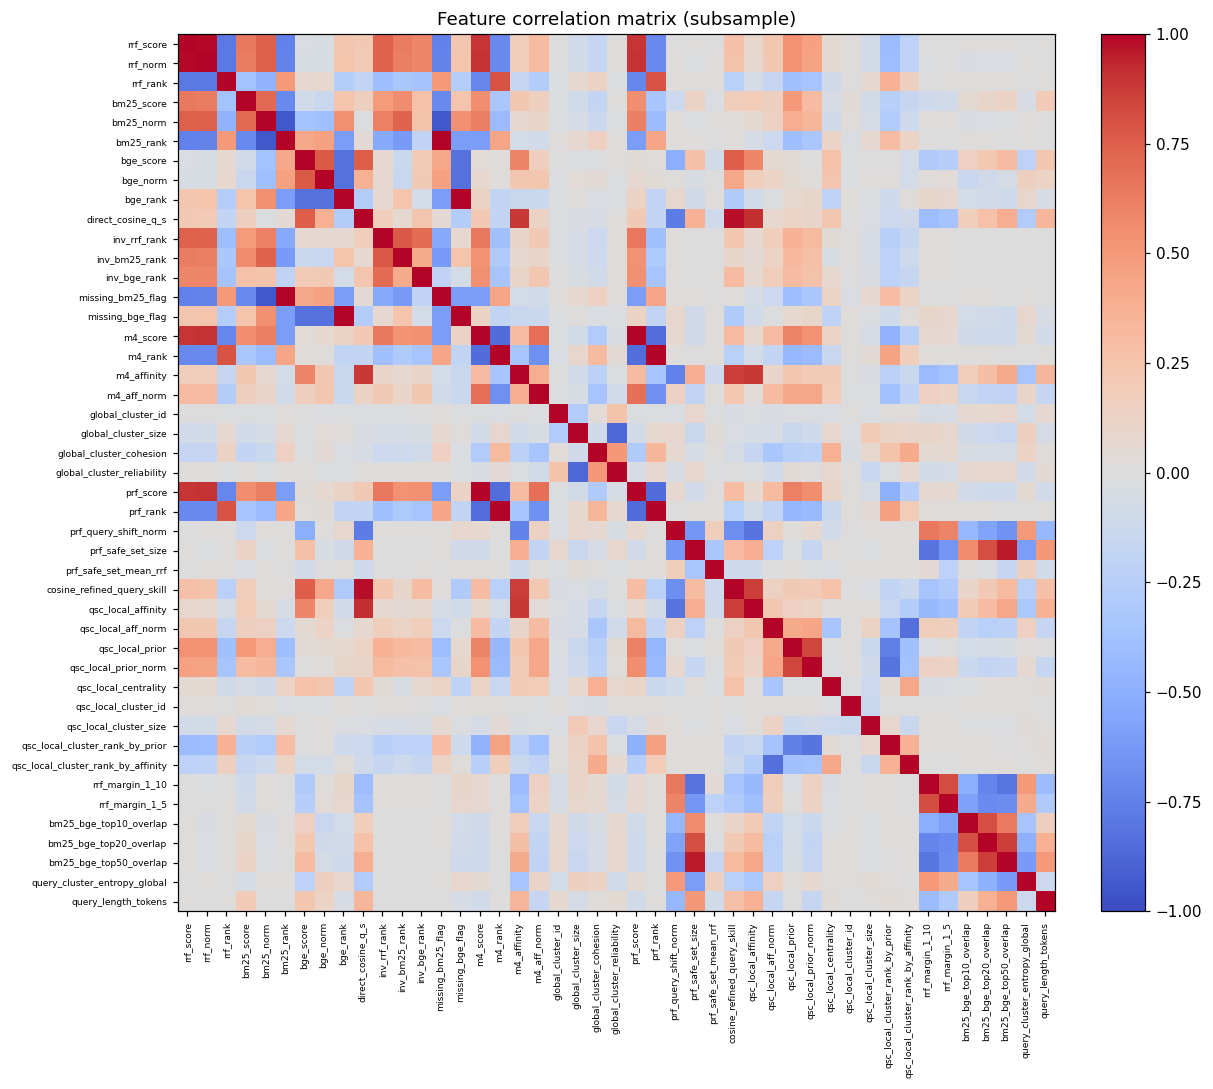

In [11]:
C = np.corrcoef(Xs.T)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS))); ax.set_xticklabels(FEATS, rotation=90, fontsize=6)
ax.set_yticks(range(len(FEATS))); ax.set_yticklabels(FEATS, fontsize=6)
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation matrix (subsample)"); plt.tight_layout(); plt.show()


## 6. Feature importance đã học (L6 LightGBM, gộp 5 fold)


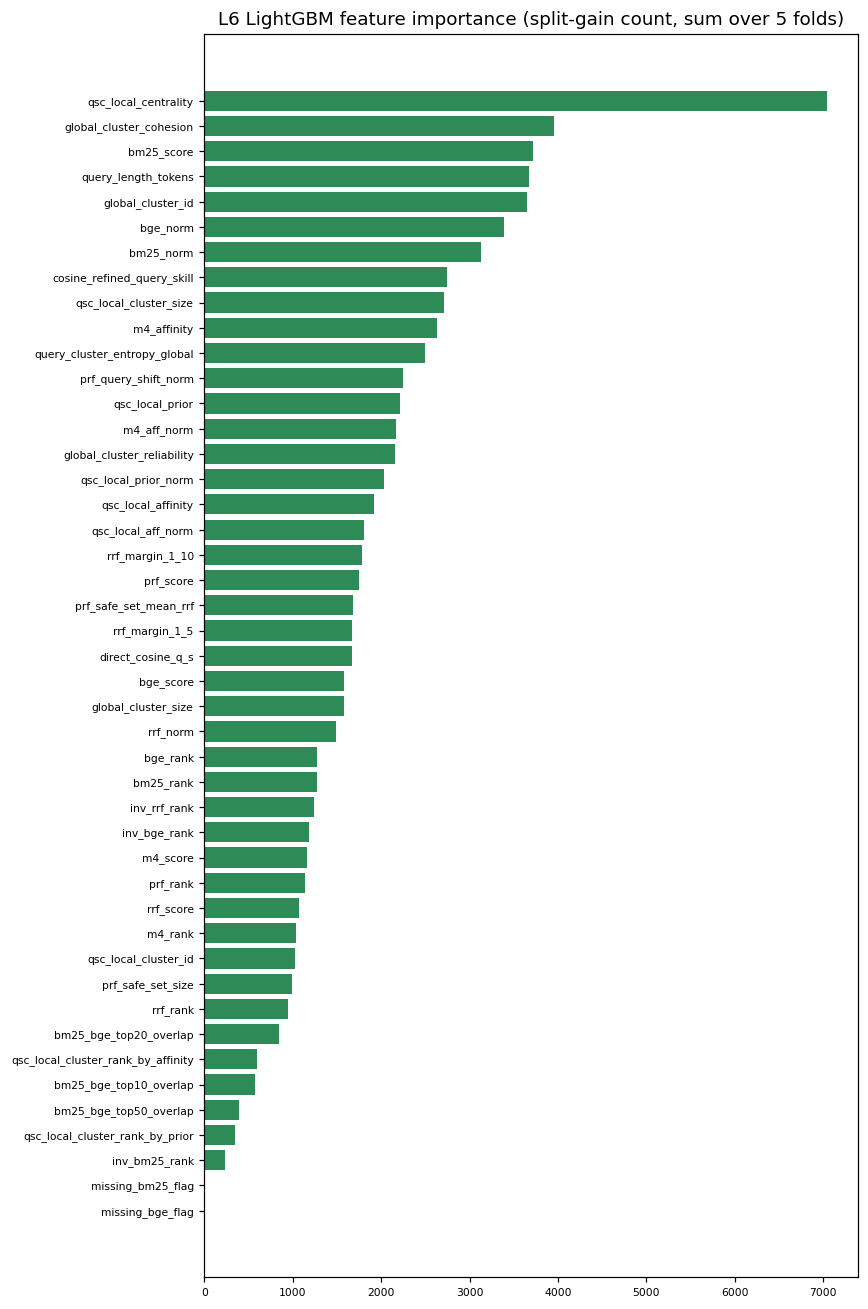

In [12]:
p = ROOT / "results/qsc_ltr/cv/cv_consolidated.json"
if p.exists():
    fi = json.loads(p.read_text())["ltr"]["L6"]["feature_importance_per_fold"]
    agg = {}
    for d in fi:
        for k, v in (d or {}).items(): agg[k] = agg.get(k, 0) + v
    s = pd.Series(agg).reindex(FEATS).fillna(0).sort_values()
    fig, ax = plt.subplots(figsize=(8, 12))
    ax.barh(s.index, s.values, color="seagreen")
    ax.set_title("L6 LightGBM feature importance (split-gain count, sum over 5 folds)")
    ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()
else:
    print("Chưa có results/qsc_ltr/cv/cv_consolidated.json — chạy run_ltr_cv.py trước.")


## 7. Chiếu PCA 2D — gold vs non-gold (all gold + 20k non-gold)


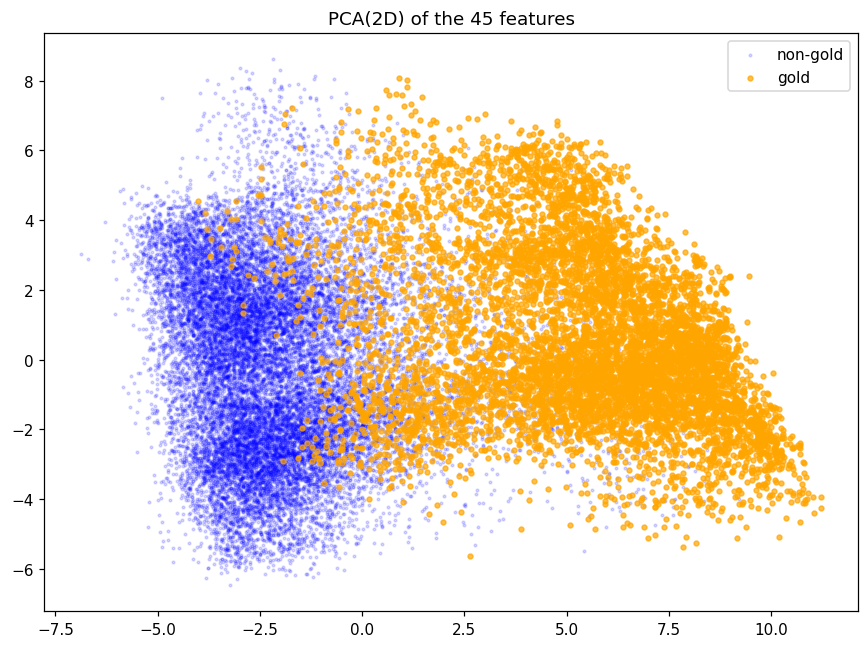

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
pos = np.where(yall == 1)[0]
neg = rng.choice(np.where(yall == 0)[0], size=min(20_000, int((yall == 0).sum())), replace=False)
sel = np.concatenate([pos, neg])
Z = PCA(n_components=2, random_state=0).fit_transform(StandardScaler().fit_transform(Xall[sel]))
ys2 = yall[sel]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z[ys2 == 0, 0], Z[ys2 == 0, 1], s=3, alpha=0.15, color="blue", label="non-gold")
ax.scatter(Z[ys2 == 1, 0], Z[ys2 == 1, 1], s=10, alpha=0.7, color="orange", label="gold")
ax.legend(); ax.set_title("PCA(2D) of the 45 features"); plt.tight_layout(); plt.show()


## 8. Một dòng feature cụ thể (ví dụ gold của 1 query)


In [17]:
def feature_row(ds, qid, sid):
    d = data[ds]; off = 0
    for i, q in enumerate(d["instance_ids"]):
        n = int(d["group_sizes"][i])
        if q == qid:
            sids = d["skill_ids"][off:off+n]
            if sid in sids:
                return d["X"][off + sids.index(sid)]
        off += n
    return None

row = feature_row("medcalcbench", "medcalcbench_00000", "medcalcbench_046")
df = pd.DataFrame({"#": range(len(FEATS)), "feature": FEATS, "value": np.round(row, 5),
                   "group": [g for f in FEATS for g, fl in GROUPS.items() if f in fl][:len(FEATS)]})
print("query=medcalcbench_00000  candidate=medcalcbench_046 (GOLD, y=1)")
df


query=medcalcbench_00000  candidate=medcalcbench_046 (GOLD, y=1)


,#,feature,value,group
0,0,rrf_score,0.026980,retrieval
1,1,rrf_norm,0.840750,retrieval
2,2,rrf_rank,9.000000,retrieval
3,3,bm25_score,251.912384,retrieval
4,4,bm25_norm,0.950280,retrieval
5,5,bm25_rank,3.000000,retrieval
6,6,bge_score,0.619110,retrieval
7,7,bge_norm,0.888220,retrieval
8,8,bge_rank,30.000000,retrieval
9,9,direct_cosine_q_s,0.619110,retrieval
